# Trustworthiness Evaluation of an LSTM Classification Model

This notebook evaluates an **LSTM** classifier against a **Logistic Regression**
baseline on a public sequential binary-classification task, across four
dimensions — **Performance, Explainability, Fairness, Robustness** — and
combines them into a **composite trust score** under three different
weighting schemes.

**Dataset:** [GunPoint](http://www.timeseriesclassification.com/description.php?Dataset=GunPoint)
(UCR/UEA Time Series Classification Archive), loaded locally through `sktime`.
200 univariate time series of length 150 (hand position while performing
one of two actions: *Gun-Draw* vs *Point*) — a standard, widely-cited public
benchmark for sequence classification.

**Why this dataset:** it is genuinely sequential (a real requirement for
testing an LSTM, unlike reshaped tabular data), small enough to train
quickly in a CPU-only environment, and simple enough that SHAP/LIME
explanations are easy to sanity-check visually.

**Important caveat — protected attribute:** GunPoint carries no demographic
metadata. Public sequence-classification datasets that *also* ship a
real demographic attribute are rare (most that do — clinical time series —
require restricted-access credentialing, e.g. PhysioNet/MIMIC). To make the
fairness section runnable end-to-end, Section 1 **simulates** a binary
"Group A / Group B" attribute using a documented, reproducible rule. This
is flagged everywhere it's used — treat the fairness numbers as a
**methodology demonstration**, not a real-world fairness audit.

---


## 0. Setup

In [1]:
# If running for the first time, uncomment:
# !pip install sktime torch shap lime fairlearn scikit-learn matplotlib pandas numpy jinja2 --quiet

import base64
import io
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import spearmanr

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              precision_score, recall_score, roc_auc_score, roc_curve)

import torch
import torch.nn as nn

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cpu')  # small model/dataset — CPU is plenty

MODEL_COLORS = {'LSTM': '#2563eb', 'Logistic Regression': '#d97706'}

def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=110)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')


## 1. Load Data & Prepare

Loads GunPoint's `TRAIN`+`TEST` splits from `sktime` (bundled locally, no
network download needed), merges them, and re-splits ourselves into
train / validation / test (70/15/15, stratified by label) so the LSTM has a
proper validation set for early stopping.

The protected attribute is simulated here — see the caveat above. The rule:
take each series' mean amplitude, add Gaussian noise, and threshold at the
median. This deliberately correlates the attribute *weakly* with the signal
(not with the label directly), which is what produces the modest — not
extreme — disparities analyzed in Section 5.


In [2]:
from sktime.datasets import load_gunpoint

Xtr_raw, ytr_raw = load_gunpoint(split='train')
Xte_raw, yte_raw = load_gunpoint(split='test')

def to_array(X):
    return np.stack([row.values for row in X.iloc[:, 0]])

X_all = np.vstack([to_array(Xtr_raw), to_array(Xte_raw)])
y_all = (np.concatenate([ytr_raw, yte_raw]).astype(int) - 1)  # '1'/'2' -> 0/1
n_samples, T = X_all.shape

print(f'Samples: {n_samples}, timesteps per series: {T}')
print('Class balance (0=Point, 1=Gun-Draw):', np.bincount(y_all))


Samples: 200, timesteps per series: 150
Class balance (0=Point, 1=Gun-Draw): [100 100]


In [5]:
X_all.shape, y_all.shape

((200, 150), (200,))

In [6]:
# --- Simulated protected attribute (see caveat in Section 1 intro) ---
rng = np.random.RandomState(RANDOM_STATE)
sig_mean = X_all.mean(axis=1)
noise = rng.normal(0, sig_mean.std() * 0.6, size=n_samples)
protected = (sig_mean + noise > np.median(sig_mean)).astype(int)  # 0='Group A', 1='Group B'
GROUP_NAMES = {0: 'Group A', 1: 'Group B'}

print('Protected-attribute balance:', np.bincount(protected))
print('Correlation(protected, label) =', round(np.corrcoef(protected, y_all)[0, 1], 3))


Protected-attribute balance: [104  96]
Correlation(protected, label) = 0.06


train=140  val=30  test=30


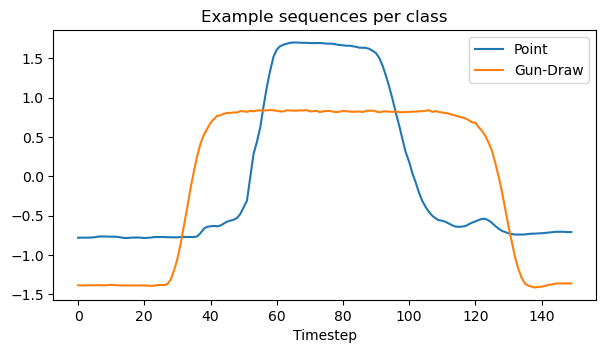

In [7]:
idx = np.arange(n_samples)
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_all[idx_temp])

scaler = StandardScaler()
scaler.fit(X_all[idx_train].reshape(-1, 1))

def scale(X):
    return scaler.transform(X.reshape(-1, 1)).reshape(X.shape)

X_train_s, X_val_s, X_test_s = scale(X_all[idx_train]), scale(X_all[idx_val]), scale(X_all[idx_test])
y_train, y_val, y_test = y_all[idx_train], y_all[idx_val], y_all[idx_test]
prot_train, prot_val, prot_test = protected[idx_train], protected[idx_val], protected[idx_test]

X_train_lstm = X_train_s[..., np.newaxis]
X_val_lstm = X_val_s[..., np.newaxis]
X_test_lstm = X_test_s[..., np.newaxis]

print(f'train={len(idx_train)}  val={len(idx_val)}  test={len(idx_test)}')

fig, ax = plt.subplots(figsize=(7, 3.5))
for lbl, name in [(0, 'Point'), (1, 'Gun-Draw')]:
    sample = X_all[idx_train][y_train == lbl][0]
    ax.plot(sample, label=name)
ax.set_title('Example sequences per class'); ax.set_xlabel('Timestep'); ax.legend()
plt.show()


## 2. Train Models

- **LSTM** — one recurrent layer over the raw (standardized) sequence, a
  small dense head, dropout for regularization, early stopping on
  validation loss.
- **Baseline — Logistic Regression** — trained on the same 150
  standardized timesteps, flattened into a feature vector. This isn't
  sequence-aware, which is exactly the point of the comparison: does the
  LSTM's ability to model temporal order actually buy performance, and at
  what cost to explainability/robustness?


In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, hidden_size=32, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, 16)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)          # h_n: (1, batch, hidden_size)
        h = torch.relu(self.fc1(h_n[-1]))    # last layer's final hidden state
        h = self.dropout(h)
        return torch.sigmoid(self.fc2(h))    # shape (batch, 1) — SHAP's GradientExplainer expects 2D output

model = LSTMClassifier(hidden_size=32, dropout=0.2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

X_train_t = torch.tensor(X_train_lstm, dtype=torch.float32, device=DEVICE)
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=DEVICE)
X_val_t = torch.tensor(X_val_lstm, dtype=torch.float32, device=DEVICE)
y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)

# --- manual training loop with early stopping on validation loss ---
MAX_EPOCHS, PATIENCE, BATCH_SIZE = 60, 8, 16
best_val_loss, epochs_no_improve, best_state = float('inf'), 0, None
n_train = len(X_train_t)

for epoch in range(MAX_EPOCHS):
    model.train()
    perm = torch.randperm(n_train)
    for start in range(0, n_train, BATCH_SIZE):
        batch_idx = perm[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        preds = model(X_train_t[batch_idx])
        loss = loss_fn(preds, y_train_t[batch_idx].unsqueeze(1))
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(model(X_val_t), y_val_t.unsqueeze(1)).item()

    if val_loss < best_val_loss - 1e-4:
        best_val_loss, epochs_no_improve = val_loss, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            break

model.load_state_dict(best_state)  # restore best-validation-loss weights
model.eval()
print(f'LSTM trained for {epoch + 1} epochs (early stopping, best val_loss={best_val_loss:.4f}).')

baseline = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
baseline.fit(X_train_s, y_train)
print('Logistic Regression trained.')


LSTM trained for 31 epochs (early stopping, best val_loss=0.5670).
Logistic Regression trained.


In [9]:
def lstm_predict_proba(X2d):
    # predict_proba-style wrapper: (n, T) flat array -> (n, 2) class probs.
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X2d.reshape(-1, T, 1), dtype=torch.float32, device=DEVICE)
        p1 = model(xt).cpu().numpy().ravel()
    return np.column_stack([1 - p1, p1])

proba_by_model = {
    'LSTM': lstm_predict_proba(X_test_s)[:, 1],
    'Logistic Regression': baseline.predict_proba(X_test_s)[:, 1],
}
pred_by_model = {name: (p > 0.5).astype(int) for name, p in proba_by_model.items()}
MODELS = list(proba_by_model)


## 3. Performance Evaluation

Accuracy, Precision, Recall, F1-score, ROC-AUC on the held-out test set,
plus ROC curves and confusion matrices for both models.


In [11]:
performance_rows = []
for name in MODELS:
    yp, ypr = pred_by_model[name], proba_by_model[name]
    performance_rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, yp),
        'precision': precision_score(y_test, yp, zero_division=0),
        'recall': recall_score(y_test, yp, zero_division=0),
        'f1_score': f1_score(y_test, yp, zero_division=0),
        'roc_auc': roc_auc_score(y_test, ypr),
    })
performance_df = pd.DataFrame(performance_rows).set_index('model')
performance_df.round(4)


,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
LSTM,0.7333,0.8889,0.5333,0.6667,0.8756
Logistic Regression,0.9000,0.9286,0.8667,0.8966,0.9200


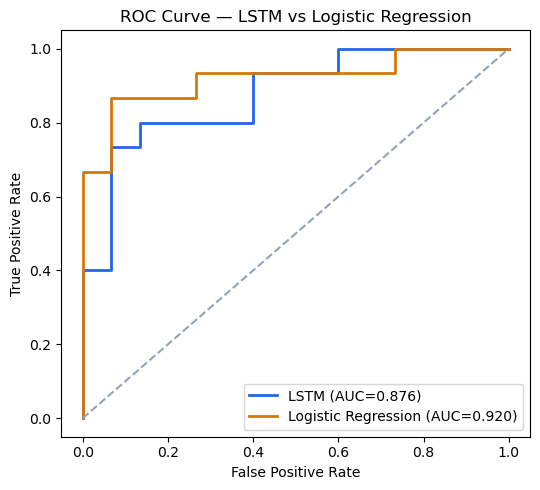

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for name in MODELS:
    fpr, tpr, _ = roc_curve(y_test, proba_by_model[name])
    ax.plot(fpr, tpr, color=MODEL_COLORS[name], linewidth=2,
            label=f'{name} (AUC={performance_df.loc[name, "roc_auc"]:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='#94a3b8')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — LSTM vs Logistic Regression'); ax.legend(loc='lower right')
fig.tight_layout()
roc_img = fig_to_base64(fig)
plt.show()


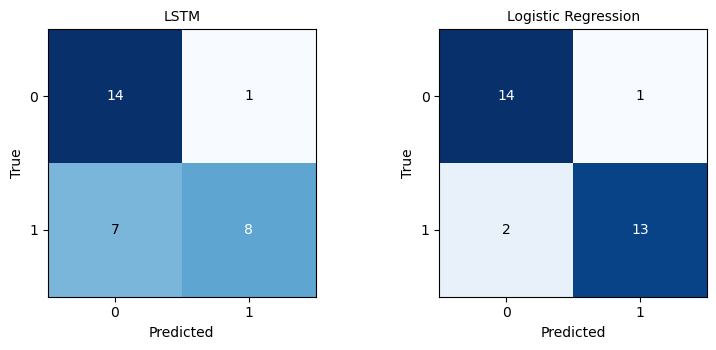

In [13]:
confusion_imgs = {}
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
for ax, name in zip(axes, MODELS):
    cm = confusion_matrix(y_test, pred_by_model[name])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name, fontsize=10); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.tight_layout()
confusion_img = fig_to_base64(fig)
plt.show()


## 4. Explainability

- **Global — SHAP `GradientExplainer`** on the LSTM: attributes each
  timestep's contribution to the prediction, averaged over a sample of test
  sequences.
- **Local — LIME** (`LimeTabularExplainer`, treating the 150 timesteps as
  tabular features) on a handful of individual predictions.
- **Global vs local comparison**: does LIME's per-instance ranking of
  important timesteps agree with SHAP's dataset-wide ranking? This
  agreement is reused as a quantitative *consistency* signal in the trust
  score (Section 7), instead of just eyeballing plots.


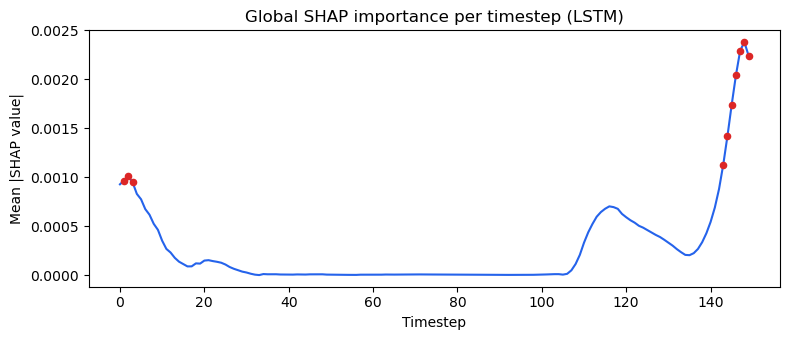

Top-10 most influential timesteps (global, SHAP): [148, 147, 149, 146, 145, 144, 143, 2, 1, 3]


In [14]:
bg_idx = rng.choice(len(X_train_lstm), size=min(40, len(X_train_lstm)), replace=False)
shap_background = torch.tensor(X_train_lstm[bg_idx], dtype=torch.float32, device=DEVICE)
shap_explain_idx = np.arange(min(40, len(X_test_lstm)))
shap_explain_set = torch.tensor(X_test_lstm[shap_explain_idx], dtype=torch.float32, device=DEVICE)

model.eval()
grad_explainer = shap.GradientExplainer(model, shap_background)
shap_values = grad_explainer.shap_values(shap_explain_set)
shap_values = np.array(shap_values).reshape(len(shap_explain_idx), T)  # (n, T)

mean_abs_shap = np.abs(shap_values).mean(axis=0)  # global importance per timestep
top10_idx = np.argsort(mean_abs_shap)[::-1][:10]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(mean_abs_shap, color=MODEL_COLORS['LSTM'])
ax.scatter(top10_idx, mean_abs_shap[top10_idx], color='#dc2626', zorder=5, s=20)
ax.set_title('Global SHAP importance per timestep (LSTM)')
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean |SHAP value|')
fig.tight_layout()
shap_global_img = fig_to_base64(fig)
plt.show()
print('Top-10 most influential timesteps (global, SHAP):', top10_idx.tolist())


In [15]:
feature_names = [f't{i}' for i in range(T)]
lime_explainer = LimeTabularExplainer(
    X_train_s, feature_names=feature_names, class_names=['Point', 'Gun-Draw'],
    discretize_continuous=False, random_state=RANDOM_STATE,
)

def lstm_lime_predict_fn(x2d):
    return lstm_predict_proba(np.asarray(x2d))

N_LIME_INSTANCES = 8
lime_sample_idx = rng.choice(len(X_test_s), size=N_LIME_INSTANCES, replace=False)

lime_explanations = {}
for i in lime_sample_idx:
    exp = lime_explainer.explain_instance(X_test_s[i], lstm_lime_predict_fn, num_features=10)
    lime_explanations[int(i)] = exp.as_list()

for i, items in list(lime_explanations.items())[:3]:
    print(f'--- Test instance {i} (true label={y_test[i]}, predicted proba={proba_by_model["LSTM"][i]:.3f}) ---')
    for feat, weight in items[:5]:
        print(f'    {feat}: {weight:+.4f}')


--- Test instance 5 (true label=1, predicted proba=0.861) ---
    t22: +0.0029
    t23: +0.0028
    t26: +0.0025
    t21: +0.0025
    t25: +0.0025
--- Test instance 19 (true label=1, predicted proba=0.854) ---
    t148: +0.0032
    t147: +0.0031
    t149: +0.0030
    t27: +0.0016
    t30: +0.0015
--- Test instance 26 (true label=1, predicted proba=0.487) ---
    t148: +0.0036
    t147: +0.0036
    t149: +0.0034
    t146: +0.0034
    t145: +0.0028


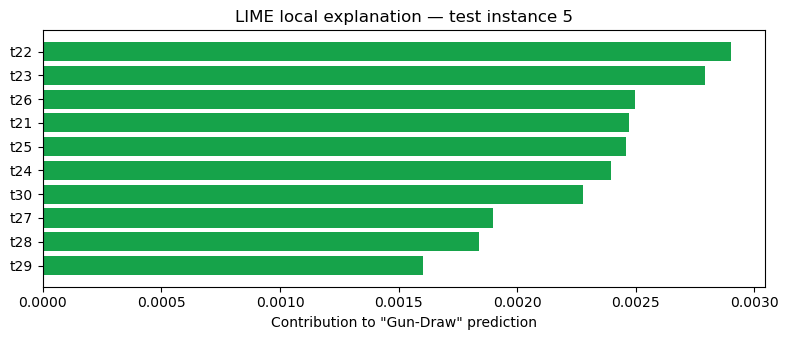

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.5))
example_i = int(lime_sample_idx[0])
items = sorted(lime_explanations[example_i], key=lambda kv: abs(kv[1]), reverse=True)
feats = [f for f, _ in items]; weights = [w for _, w in items]
colors = ['#16a34a' if w > 0 else '#dc2626' for w in weights]
ax.barh(feats[::-1], weights[::-1], color=colors[::-1])
ax.set_title(f'LIME local explanation — test instance {example_i}')
ax.set_xlabel('Contribution to "Gun-Draw" prediction')
fig.tight_layout()
lime_local_img = fig_to_base64(fig)
plt.show()


### Global SHAP vs local LIME — agreement check

For every LIME-explained instance, rank its 10 reported timesteps by
`|weight|` and compare that local ranking against the same timesteps'
ranks in the global SHAP importance (`mean_abs_shap`), using Spearman rank
correlation. Averaged across instances, this gives a single
**global–local consistency score** — reused directly as a component of the
Explainability module score in Section 7 (see the justification there for
why this beats an arbitrary hand-picked ranking).


In [17]:
def local_global_consistency(lime_explanations, mean_abs_shap):
    rhos = []
    for i, items in lime_explanations.items():
        t_idx = [int(f[1:]) for f, _ in items]          # 't37' -> 37
        local_w = np.abs([w for _, w in items])
        global_w = mean_abs_shap[t_idx]
        if len(set(t_idx)) < 3:
            continue
        rho, _ = spearmanr(local_w, global_w)
        if not np.isnan(rho):
            rhos.append(rho)
    return float(np.mean(rhos)) if rhos else np.nan

lstm_consistency = local_global_consistency(lime_explanations, mean_abs_shap)
print(f'Mean Spearman rank correlation (LIME local vs SHAP global), LSTM: {lstm_consistency:.3f}')


Mean Spearman rank correlation (LIME local vs SHAP global), LSTM: 0.911


In [18]:
# --- Baseline (Logistic Regression) explainability, for a like-for-like comparison ---
# LR's coefficients ARE its global explanation, and (being linear) also exactly
# describe every local prediction -> local/global consistency is 1.0 by construction.
lr_importance = np.abs(baseline.coef_[0])
lr_consistency = 1.0
print('Logistic Regression: local/global consistency = 1.0 (linear model, by construction)')


Logistic Regression: local/global consistency = 1.0 (linear model, by construction)


## 5. Fairness Evaluation

Protected attribute: the simulated **Group A / Group B** split from Section 1.
Metrics (computed manually from group-wise confusion matrices so the exact
formula is visible):

| Metric | Formula | Ideal |
|---|---|---|
| Statistical Parity Difference (SPD) | `P(ŷ=1｜B) − P(ŷ=1｜A)` | 0 |
| Disparate Impact Ratio (DIR) | `min(sel_A,sel_B) / max(sel_A,sel_B)` | 1 |
| Equal Opportunity Difference (EOD) | `TPR_B − TPR_A` | 0 |
| Average Odds Difference (AOD) | `0.5·[(FPR_B−FPR_A) + (TPR_B−TPR_A)]` | 0 |

computed for **both** models, so the comparison itself is meaningful.


In [19]:
def group_confusion_stats(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1)); fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0)); fn = np.sum((y_true == 1) & (y_pred == 0))
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    selection_rate = (tp + fp) / max(tp + fp + tn + fn, 1)
    return {'tpr': tpr, 'fpr': fpr, 'selection_rate': selection_rate}

def fairness_metrics(y_true, y_pred, group):
    gA, gB = group == 0, group == 1
    sA, sB = group_confusion_stats(y_true[gA], y_pred[gA]), group_confusion_stats(y_true[gB], y_pred[gB])
    spd = sB['selection_rate'] - sA['selection_rate']
    lo, hi = sorted([sA['selection_rate'], sB['selection_rate']])
    dir_ = lo / hi if hi > 0 else np.nan
    eod = sB['tpr'] - sA['tpr']
    aod = 0.5 * ((sB['fpr'] - sA['fpr']) + (sB['tpr'] - sA['tpr']))
    return {
        'selection_rate_A': sA['selection_rate'], 'selection_rate_B': sB['selection_rate'],
        'tpr_A': sA['tpr'], 'tpr_B': sB['tpr'], 'fpr_A': sA['fpr'], 'fpr_B': sB['fpr'],
        'statistical_parity_difference': spd, 'disparate_impact_ratio': dir_,
        'equal_opportunity_difference': eod, 'average_odds_difference': aod,
    }

fairness_rows = []
for name in MODELS:
    row = {'model': name}
    row.update(fairness_metrics(y_test, pred_by_model[name], prot_test))
    fairness_rows.append(row)
fairness_df = pd.DataFrame(fairness_rows).set_index('model')
fairness_df.round(4)


,selection_rate_A,selection_rate_B,tpr_A,tpr_B,fpr_A,fpr_B,statistical_parity_difference,disparate_impact_ratio,equal_opportunity_difference,average_odds_difference
model,,,,,,,,,,
LSTM,0.1875,0.4286,0.4286,0.625,0.0000,0.1667,0.2411,0.4375,0.1964,0.1815
Logistic Regression,0.4375,0.5000,0.8571,0.875,0.1111,0.0000,0.0625,0.8750,0.0179,-0.0466


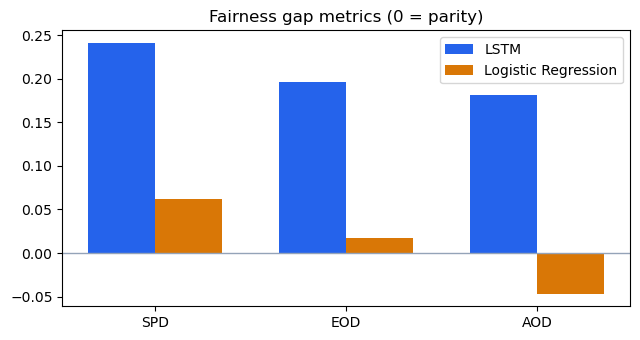

In [20]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
metrics_to_plot = ['statistical_parity_difference', 'equal_opportunity_difference', 'average_odds_difference']
x = np.arange(len(metrics_to_plot)); width = 0.35
for i, name in enumerate(MODELS):
    vals = [fairness_df.loc[name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=name, color=MODEL_COLORS[name])
ax.axhline(0, color='#94a3b8', linewidth=1)
ax.set_xticks(x + width / 2); ax.set_xticklabels(['SPD', 'EOD', 'AOD'])
ax.set_title('Fairness gap metrics (0 = parity)'); ax.legend()
fig.tight_layout()
fairness_img = fig_to_base64(fig)
plt.show()


## 6. Robustness — Gaussian Noise + Timestep Masking

Two independent perturbation sweeps, applied to the (already standardized)
test sequences, for both models:

1. **Gaussian noise** — add `N(0, level·σ)` to every timestep, `level` in
   `{0, 0.05, 0.10, 0.20, 0.35}` (fraction of the training-set feature std).
2. **Timestep masking / feature dropout** — randomly replace a fraction of
   individual timesteps with the training-set median value at that
   timestep, `rate` in the same set. Simulates missing/corrupted readings.

Accuracy and F1-score are tracked at each level.


In [21]:
noise_levels = (0.0, 0.05, 0.10, 0.20, 0.35)
train_std = X_train_s.std()
train_timestep_median = np.median(X_train_s, axis=0)  # (T,)

def apply_gaussian_noise(X2d, level, rng_):
    if level == 0:
        return X2d
    return X2d + rng_.normal(0, level * train_std, size=X2d.shape)

def apply_timestep_masking(X2d, rate, rng_):
    if rate == 0:
        return X2d
    mask = rng_.rand(*X2d.shape) < rate
    X_out = X2d.copy()
    X_out[mask] = np.broadcast_to(train_timestep_median, X2d.shape)[mask]
    return X_out

def predict_for(name, X2d):
    if name == 'LSTM':
        return (lstm_predict_proba(X2d)[:, 1] > 0.5).astype(int)
    return baseline.predict(X2d)

def run_perturbation_sweep(apply_fn, levels, level_name):
    rows = []
    for name in MODELS:
        rng_ = np.random.RandomState(RANDOM_STATE)
        for level in levels:
            X_pert = apply_fn(X_test_s, level, rng_)
            yp = predict_for(name, X_pert)
            rows.append({
                'model': name, level_name: level,
                'accuracy': accuracy_score(y_test, yp),
                'f1_score': f1_score(y_test, yp, zero_division=0),
            })
    return pd.DataFrame(rows)

noise_df = run_perturbation_sweep(apply_gaussian_noise, noise_levels, 'noise_level')
mask_df = run_perturbation_sweep(apply_timestep_masking, noise_levels, 'mask_rate')
noise_df.round(4)


,model,noise_level,accuracy,f1_score
0,LSTM,0.00,0.7333,0.6667
1,LSTM,0.05,0.7333,0.6667
2,LSTM,0.10,0.7333,0.6667
3,LSTM,0.20,0.7333,0.6667
4,LSTM,0.35,0.7000,0.6400
5,Logistic Regression,0.00,0.9000,0.8966
6,Logistic Regression,0.05,0.9000,0.8966
7,Logistic Regression,0.10,0.8667,0.8571
8,Logistic Regression,0.20,0.8667,0.8571
9,Logistic Regression,0.35,0.8333,0.8387


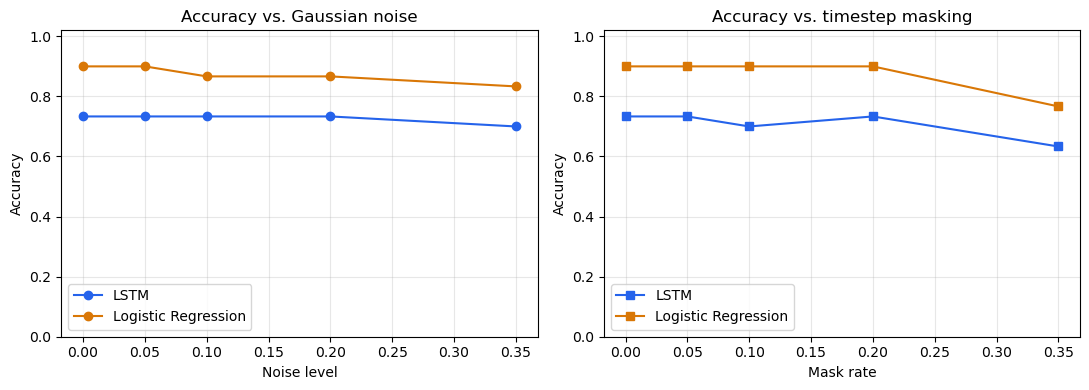

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in MODELS:
    sub = noise_df[noise_df['model'] == name]
    axes[0].plot(sub['noise_level'], sub['accuracy'], marker='o', color=MODEL_COLORS[name], label=name)
    sub2 = mask_df[mask_df['model'] == name]
    axes[1].plot(sub2['mask_rate'], sub2['accuracy'], marker='s', color=MODEL_COLORS[name], label=name)
axes[0].set_title('Accuracy vs. Gaussian noise'); axes[0].set_xlabel('Noise level')
axes[1].set_title('Accuracy vs. timestep masking'); axes[1].set_xlabel('Mask rate')
for ax in axes:
    ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout()
robustness_img = fig_to_base64(fig)
plt.show()


In [23]:
def mean_relative_drop(df, level_col):
    out = {}
    for name in MODELS:
        sub = df[df['model'] == name].sort_values(level_col)
        baseline_acc = sub.iloc[0]['accuracy']
        drops = baseline_acc - sub[sub[level_col] > 0]['accuracy']
        out[name] = drops.mean()
    return out

noise_drop = mean_relative_drop(noise_df, 'noise_level')
mask_drop = mean_relative_drop(mask_df, 'mask_rate')

robustness_summary_df = pd.DataFrame({
    'mean_accuracy_drop_noise': noise_drop,
    'mean_accuracy_drop_masking': mask_drop,
})
robustness_summary_df['mean_accuracy_drop_overall'] = robustness_summary_df.mean(axis=1)
robustness_summary_df.round(4)


,mean_accuracy_drop_noise,mean_accuracy_drop_masking,mean_accuracy_drop_overall
LSTM,0.0083,0.0333,0.0208
Logistic Regression,0.0333,0.0333,0.0333


## 7. Trustworthiness Scoring

Four module scores (Performance, Explainability, Fairness, Robustness) are
each computed on a transparent, fixed formula, kept in `[0, 1]` where
**1 = best**, then combined into a composite score under three weighting
configurations. Every design choice below is called out explicitly.

### 7.1 How each module score is calculated

**Performance module score**
```
performance_score = clip( (ROC_AUC - 0.5) / (1.0 - 0.5), 0, 1 )
```
*Manual choice:* rather than min-max-normalizing across just the two
candidate models (which — with only two points — trivially forces one
score to 0 and the other to 1, hiding how close they actually are), ROC-AUC
is rescaled against the **domain-meaningful fixed range [0.5, 1.0]**
(0.5 = random guessing, 1.0 = perfect separation). This keeps the score
comparable if more models are added later, and reflects "how far above
chance" rather than "who's the local winner."

**Explainability module score** — see §7.2, it is not a simple ranking.

**Fairness module score**
```
fairness_score = mean( 1-|SPD|,  min(DIR, 1/DIR),  1-|EOD|,  1-|AOD| )
```
Each of the four sub-terms is already bounded to `[0, 1]` with 1 = perfect
parity/no gap (DIR is symmetrized via `min(DIR, 1/DIR)` so it doesn't
matter which group has the higher rate). *Manual choice:* equal (0.25)
weight across the four fairness sub-metrics — no single one is treated as
authoritative, per the fairness-is-multidimensional point in the README of
the earlier project this notebook builds on.

**Robustness module score**
```
robustness_score = clip( 1 - mean_accuracy_drop_overall, 0, 1 )
```
where `mean_accuracy_drop_overall` is the Section 6 result: the mean
accuracy drop from the clean baseline, averaged over every non-zero noise
level *and* every non-zero masking rate.

**Composite trust score**
```
composite = w_perf·performance_score + w_expl·explainability_score
          + w_fair·fairness_score     + w_rob·robustness_score
```
with three manually chosen `(w_perf, w_expl, w_fair, w_rob)` weight sets,
defined in §7.3.

### 7.2 Explainability score — justified, not just ranked

A defensible explainability score needs more than "linear models rank
above tree/neural models by assumption." Three measurable ingredients are
combined instead:

1. **Concentration `C`** — share of total global importance
   (`mean(|SHAP|)` for the LSTM, `mean(|coef|)` for Logistic Regression)
   captured by the top-3 most important features. High concentration means
   a handful of inputs tell most of the story — easier to audit/summarize.
2. **Global–local consistency `ρ`** — the Section 4 Spearman correlation
   between LIME's local rankings and the SHAP/coefficient global ranking,
   averaged over sampled instances (1.0 by construction for the linear
   baseline). Low consistency would mean "the global picture doesn't
   actually describe individual decisions" — a real explainability
   weakness that a pure architecture-based ranking would miss entirely.
3. **Inherent interpretability `I ∈ {0, 1}`** — 1 if the model's decision
   function is directly human-readable without any post-hoc tool (true for
   Logistic Regression's coefficients; false for the LSTM).

```
explainability_score = 0.4·C + 0.4·ρ + 0.2·I
```
*Manual choices, stated explicitly:* the `0.4 / 0.4 / 0.2` weighting
(concentration and consistency are treated as equally important
data-driven signals; inherent interpretability gets a smaller, tie-breaking
weight since it's a binary architectural fact rather than a measured
property), and the choice of top-3 for concentration.

### 7.3 Three weighting configurations


In [24]:
WEIGHT_CONFIGS = {
    'Performance-focused': {'performance': 0.55, 'fairness': 0.15, 'robustness': 0.20, 'explainability': 0.10},
    'Fairness-focused':    {'performance': 0.15, 'fairness': 0.55, 'robustness': 0.15, 'explainability': 0.15},
    'Balanced':            {'performance': 0.25, 'fairness': 0.25, 'robustness': 0.25, 'explainability': 0.25},
}
pd.DataFrame(WEIGHT_CONFIGS).T


,performance,fairness,robustness,explainability
Performance-focused,0.55,0.15,0.20,0.10
Fairness-focused,0.15,0.55,0.15,0.15
Balanced,0.25,0.25,0.25,0.25


In [25]:
def clip01(x):
    return float(np.clip(x, 0, 1))

# --- Performance module ---
performance_score = {name: clip01((performance_df.loc[name, 'roc_auc'] - 0.5) / 0.5) for name in MODELS}

# --- Explainability module ---
def concentration_top3(importances):
    v = np.sort(np.abs(importances))[::-1]
    return float(v[:3].sum() / v.sum()) if v.sum() > 0 else np.nan

concentration = {
    'LSTM': concentration_top3(mean_abs_shap),
    'Logistic Regression': concentration_top3(lr_importance),
}
consistency = {'LSTM': lstm_consistency, 'Logistic Regression': lr_consistency}
inherent = {'LSTM': 0, 'Logistic Regression': 1}

explainability_score = {
    name: clip01(0.4 * concentration[name] + 0.4 * consistency[name] + 0.2 * inherent[name])
    for name in MODELS
}

# --- Fairness module ---
def fairness_module_score(row):
    dir_ = row['disparate_impact_ratio']
    dir_term = min(dir_, 1 / dir_) if dir_ and dir_ > 0 else 0.0
    return float(np.mean([
        1 - abs(row['statistical_parity_difference']),
        dir_term,
        1 - abs(row['equal_opportunity_difference']),
        1 - abs(row['average_odds_difference']),
    ]))

fairness_score = {name: clip01(fairness_module_score(fairness_df.loc[name])) for name in MODELS}

# --- Robustness module ---
robustness_score = {name: clip01(1 - robustness_summary_df.loc[name, 'mean_accuracy_drop_overall']) for name in MODELS}

module_scores_df = pd.DataFrame({
    'performance_score': performance_score,
    'explainability_score': explainability_score,
    'fairness_score': fairness_score,
    'robustness_score': robustness_score,
})
module_scores_df.round(4)


,performance_score,explainability_score,fairness_score,robustness_score
LSTM,0.7511,0.4333,0.7046,0.9792
Logistic Regression,0.8400,0.6274,0.9370,0.9667


### Raw metrics kept alongside normalized scores

Every normalized module score above traces back to the raw metric(s) it was
built from — nothing is hidden behind the `[0,1]` scale.


In [26]:
raw_vs_normalized = pd.concat([
    performance_df[['roc_auc', 'accuracy', 'f1_score']],
    pd.DataFrame({'concentration_top3': concentration, 'local_global_consistency': consistency,
                  'inherently_interpretable': inherent}),
    fairness_df[['statistical_parity_difference', 'disparate_impact_ratio',
                 'equal_opportunity_difference', 'average_odds_difference']],
    robustness_summary_df[['mean_accuracy_drop_overall']],
    module_scores_df,
], axis=1)
raw_vs_normalized.round(4).T


,LSTM,Logistic Regression
roc_auc,0.8756,0.9200
accuracy,0.7333,0.9000
f1_score,0.6667,0.8966
concentration_top3,0.1725,0.0684
local_global_consistency,0.9106,1.0000
inherently_interpretable,0.0000,1.0000
statistical_parity_difference,0.2411,0.0625
disparate_impact_ratio,0.4375,0.8750
equal_opportunity_difference,0.1964,0.0179
average_odds_difference,0.1815,-0.0466


In [27]:
composite_rows = []
for config_name, weights in WEIGHT_CONFIGS.items():
    for name in MODELS:
        composite = (weights['performance'] * performance_score[name]
                     + weights['explainability'] * explainability_score[name]
                     + weights['fairness'] * fairness_score[name]
                     + weights['robustness'] * robustness_score[name])
        composite_rows.append({'weighting': config_name, 'model': name, 'composite_score': composite})

composite_df = pd.DataFrame(composite_rows)
composite_pivot = composite_df.pivot(index='model', columns='weighting', values='composite_score')
composite_pivot = composite_pivot[list(WEIGHT_CONFIGS)]  # keep declared column order
composite_pivot.round(4)


weighting,Performance-focused,Fairness-focused,Balanced
model,,,
LSTM,0.7580,0.7121,0.7170
Logistic Regression,0.8586,0.8805,0.8428


In [28]:
winners = composite_pivot.idxmax(axis=0)
print('Selected (highest composite score) model under each weighting scheme:')
for config_name, winner in winners.items():
    print(f'  {config_name:<22} -> {winner}  (score={composite_pivot.loc[winner, config_name]:.4f})')

if winners.nunique() == 1:
    print(f'\nThe selected model does NOT change across weighting schemes: always "{winners.iloc[0]}".')
else:
    print('\nThe selected model CHANGES depending on the weighting scheme — model choice is weight-dependent.')


Selected (highest composite score) model under each weighting scheme:
  Performance-focused    -> Logistic Regression  (score=0.8586)
  Fairness-focused       -> Logistic Regression  (score=0.8805)
  Balanced               -> Logistic Regression  (score=0.8428)

The selected model does NOT change across weighting schemes: always "Logistic Regression".


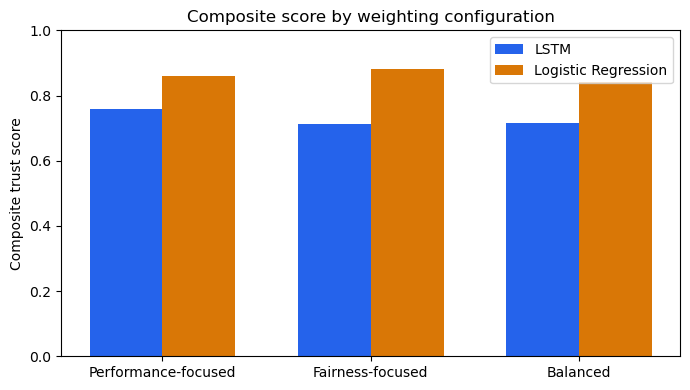

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(WEIGHT_CONFIGS)); width = 0.35
for i, name in enumerate(MODELS):
    vals = [composite_pivot.loc[name, c] for c in WEIGHT_CONFIGS]
    ax.bar(x + i * width, vals, width, label=name, color=MODEL_COLORS[name])
ax.set_xticks(x + width / 2); ax.set_xticklabels(list(WEIGHT_CONFIGS))
ax.set_ylabel('Composite trust score'); ax.set_ylim(0, 1)
ax.set_title('Composite score by weighting configuration'); ax.legend()
fig.tight_layout()
composite_img = fig_to_base64(fig)
plt.show()


## 8. Generate HTML Report

Assembles everything above — performance, explainability, fairness,
robustness, and the full scoring breakdown across all three weighting
configurations — into a single self-contained HTML file
(`lstm_trust_report.html`), with every chart embedded as a base64 image so
the file works standalone (no external assets, opens in any browser,
easy to share or attach to the thesis writeup).


In [30]:
from jinja2 import Template

REPORT_TEMPLATE = Template(r'''
<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
<title>{{ report_title }}</title>
<style>
  :root { --ink:#1e293b; --muted:#64748b; --line:#e2e8f0; --bg-card:#f8fafc;
          --good:#16a34a; --warn:#d97706; --bad:#dc2626; }
  * { box-sizing: border-box; }
  body { font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
         color: var(--ink); max-width: 1080px; margin: 0 auto; padding: 40px 24px 80px; line-height: 1.5; }
  .section{ background:#fff; border:1px solid #e5e7eb; border-radius:14px; padding:24px;
            margin:32px 0; box-shadow:0 3px 12px rgba(0,0,0,.05); }
  h1 { font-size: 28px; margin-bottom: 4px; }
  .subtitle { color: var(--muted); font-size: 14px; margin-bottom: 36px; }
  h2 { font-size: 20px; border-bottom: 2px solid var(--line); padding-bottom: 8px; margin-top: 48px; }
  h3 { font-size: 16px; margin-top: 24px; }
  .img-row { display: flex; gap: 20px; flex-wrap: wrap; margin: 20px 0; justify-content: center; }
  .img-row img { max-width: 480px; width: 100%; border: 1px solid var(--line); border-radius: 8px; }
  table { border-collapse: collapse; width: 100%; overflow: hidden; border-radius: 12px; margin: 16px 0; font-size: 13px; }
  thead { background: #1e40af; color: white; }
  th, td { padding: 8px 12px; text-align: left; }
  tbody tr:nth-child(even) { background: #f8fafc; }
  tbody tr:hover { background: #eff6ff; }
  .note { background:#eff6ff; border-left:5px solid #2563eb; padding:15px; border-radius:10px; color:#334155; margin-top:15px; }
  .caveat { background:#fffbeb; border-left:5px solid #d97706; padding:15px; border-radius:10px; color:#334155; margin:20px 0; }
  .badge { display:inline-block; padding:4px 10px; border-radius:999px; font-size:12px; font-weight:600; color:white; margin:2px 4px 2px 0; }
  .badge.best { background:var(--good); }
  .badge.risk { background:var(--bad); }
  .badge.robust { background:#0891b2; }
  .badge.explain { background:#7c3aed; }
  .badge.win { background:#1d4ed8; }
  footer { margin-top: 60px; color: var(--muted); font-size: 12px; text-align: center; }
  .hero { background: linear-gradient(135deg,#1d4ed8,#2563eb); color:white; padding:35px; border-radius:16px; margin-bottom:35px; }
  .hero h1 { margin:0; color:white; }
  .hero p { margin:10px 0 20px; opacity:.95; }
  .hero-info { display:flex; gap:25px; flex-wrap:wrap; font-size:14px; }
  code { background:#f1f5f9; padding:1px 5px; border-radius:4px; font-size:12px; }
</style></head><body>

<div class="hero">
  <h1>{{ report_title }}</h1>
  <p>LSTM vs. Logistic Regression baseline, evaluated on predictive performance,
     explainability, fairness, and robustness — combined into a composite trust
     score under three weighting configurations.</p>
  <div class="hero-info">
    <span><b>Generated:</b> {{ generated_at }}</span>
    <span><b>Dataset:</b> {{ dataset_name }} ({{ n_samples }} sequences, {{ n_timesteps }} timesteps)</span>
    <span><b>Test samples:</b> {{ test_set_size }}</span>
  </div>
</div>

<div class="caveat">
  <b>Protected-attribute caveat:</b> {{ dataset_name }} carries no real demographic
  metadata. The "Group A / Group B" attribute used throughout the Fairness section
  is <b>simulated</b> from the signal's mean amplitude plus injected noise (see
  notebook §1) so the fairness methodology can be demonstrated end-to-end. Treat
  the fairness results below as a methodology demonstration, not a real-world
  fairness audit.
</div>

<div class="section">
  <h2>Trust Summary</h2>
  <p>
    <span class="badge best">Best performance: {{ best_performance_model }}</span>
    <span class="badge explain">Most explainable: {{ most_explainable_model }}</span>
    <span class="badge risk">Highest fairness risk: {{ highest_fairness_risk_model }}</span>
    <span class="badge robust">Most robust: {{ most_robust_model }}</span>
  </p>
  <table>
    <tr><th>Model</th><th>Performance score</th><th>Explainability score</th><th>Fairness score</th><th>Robustness score</th></tr>
    {% for row in module_score_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.performance_score) }}</td>
        <td>{{ "%.3f"|format(row.explainability_score) }}</td>
        <td>{{ "%.3f"|format(row.fairness_score) }}</td>
        <td>{{ "%.3f"|format(row.robustness_score) }}</td></tr>
    {% endfor %}
  </table>
  <h3>Composite score by weighting configuration</h3>
  <table>
    <tr><th>Model</th>{% for cfg in weight_configs %}<th>{{ cfg }}</th>{% endfor %}</tr>
    {% for model in model_names %}
    <tr><td>{{ model }}</td>
      {% for cfg in weight_configs %}
        <td {% if winners[cfg] == model %}style="font-weight:700;color:var(--good)"{% endif %}>
          {{ "%.3f"|format(composite_pivot[cfg][model]) }}{% if winners[cfg] == model %} <span class="badge win">selected</span>{% endif %}
        </td>
      {% endfor %}
    </tr>
    {% endfor %}
  </table>
  <div class="note">
    {% if selection_changes %}
      The selected (highest composite score) model <b>changes</b> depending on the weighting scheme.
    {% else %}
      The selected (highest composite score) model is <b>{{ winners.values()|list|first }}</b> under
      every one of the three weighting schemes tested — see §5 for the weights that would need to
      change for this to flip.
    {% endif %}
  </div>
</div>

<div class="section">
  <h2>1. Model Performance</h2>
  <table>
    <tr><th>Model</th><th>Accuracy</th><th>Precision</th><th>Recall</th><th>F1</th><th>ROC-AUC</th></tr>
    {% for row in performance_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.accuracy) }}</td><td>{{ "%.3f"|format(row.precision) }}</td>
        <td>{{ "%.3f"|format(row.recall) }}</td><td>{{ "%.3f"|format(row.f1_score) }}</td><td>{{ "%.3f"|format(row.roc_auc) }}</td></tr>
    {% endfor %}
  </table>
  <div class="img-row"><img src="data:image/png;base64,{{ roc_img }}"></div>
  <h3>Confusion matrices</h3>
  <div class="img-row"><img src="data:image/png;base64,{{ confusion_img }}"></div>
</div>

<div class="section">
  <h2>2. Explainability — Global SHAP vs. Local LIME</h2>
  <table>
    <tr><th>Model</th><th>Top-3 concentration</th><th>Local–global consistency</th><th>Inherently interpretable</th><th>Explainability score</th></tr>
    {% for row in explainability_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.concentration_top3) }}</td>
        <td>{{ "%.3f"|format(row.local_global_consistency) }}</td>
        <td>{{ 'Yes' if row.inherently_interpretable else 'No (post-hoc only)' }}</td>
        <td><b>{{ "%.3f"|format(row.explainability_score) }}</b></td></tr>
    {% endfor %}
  </table>
  <h3>Global SHAP importance (LSTM)</h3>
  <div class="img-row"><img src="data:image/png;base64,{{ shap_global_img }}"></div>
  <h3>Example local LIME explanation (LSTM)</h3>
  <div class="img-row"><img src="data:image/png;base64,{{ lime_local_img }}"></div>
  <div class="note">Explainability score = 0.4·concentration + 0.4·local–global consistency +
    0.2·inherent interpretability. Logistic Regression scores 1.0 on consistency and
    inherent interpretability by construction (a linear model's coefficients ARE its
    local explanation); the LSTM's score depends entirely on the two measured SHAP/LIME
    properties.</div>
</div>

<div class="section">
  <h2>3. Fairness Metrics</h2>
  <p>Group fairness across the simulated Group A / Group B attribute (see caveat above).
     Disparate impact ratio below 0.8 is commonly flagged by the "four-fifths rule".</p>
  <table>
    <tr><th>Model</th><th>Sel. rate A</th><th>Sel. rate B</th><th>SPD</th><th>DIR</th><th>EOD</th><th>AOD</th></tr>
    {% for row in fairness_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.3f"|format(row.selection_rate_A) }}</td><td>{{ "%.3f"|format(row.selection_rate_B) }}</td>
        <td>{{ "%.3f"|format(row.statistical_parity_difference) }}</td>
        <td {% if row.disparate_impact_ratio < 0.8 %}style="color:var(--bad);font-weight:600"{% endif %}>{{ "%.3f"|format(row.disparate_impact_ratio) }}</td>
        <td>{{ "%.3f"|format(row.equal_opportunity_difference) }}</td>
        <td>{{ "%.3f"|format(row.average_odds_difference) }}</td></tr>
    {% endfor %}
  </table>
  <div class="img-row"><img src="data:image/png;base64,{{ fairness_img }}"></div>
</div>

<div class="section">
  <h2>4. Robustness — Gaussian Noise + Timestep Masking</h2>
  <div class="img-row"><img src="data:image/png;base64,{{ robustness_img }}"></div>
  <table>
    <tr><th>Model</th><th>Mean accuracy drop — noise</th><th>Mean accuracy drop — masking</th><th>Mean accuracy drop — overall</th></tr>
    {% for row in robustness_rows %}
    <tr><td>{{ row.model }}</td><td>{{ "%.4f"|format(row.mean_accuracy_drop_noise) }}</td>
        <td>{{ "%.4f"|format(row.mean_accuracy_drop_masking) }}</td>
        <td><b>{{ "%.4f"|format(row.mean_accuracy_drop_overall) }}</b></td></tr>
    {% endfor %}
  </table>
</div>

<div class="section">
  <h2>5. Trustworthiness Scoring</h2>
  <table>
    <tr><th>Weighting</th><th>Performance</th><th>Fairness</th><th>Robustness</th><th>Explainability</th></tr>
    {% for cfg, w in weights_used.items() %}
    <tr><td>{{ cfg }}</td><td>{{ w.performance }}</td><td>{{ w.fairness }}</td><td>{{ w.robustness }}</td><td>{{ w.explainability }}</td></tr>
    {% endfor %}
  </table>
  <div class="img-row"><img src="data:image/png;base64,{{ composite_img }}"></div>
  <div class="note">
    <b>Manually-chosen elements:</b> ROC-AUC normalized against the fixed range [0.5, 1.0]
    (random-guess floor to perfect separation) rather than min-max across the two models;
    explainability sub-weights 0.4 / 0.4 / 0.2; equal (0.25) weight across the four fairness
    sub-metrics; the three composite weighting configurations themselves; and the
    simulated-protected-attribute generation rule. See notebook §7 for the full derivation.
  </div>
</div>

<footer>Generated by the LSTM Trustworthiness Evaluation notebook · {{ generated_at }}</footer>
</body></html>
''')


In [31]:
explainability_table_df = pd.DataFrame({
    'concentration_top3': concentration,
    'local_global_consistency': consistency,
    'inherently_interpretable': inherent,
    'explainability_score': explainability_score,
})

module_score_rows = module_scores_df.reset_index().rename(columns={'index': 'model'}).to_dict('records')
performance_rows_r = performance_df.reset_index().to_dict('records')
explainability_rows_r = explainability_table_df.reset_index().rename(columns={'index': 'model'}).to_dict('records')
fairness_rows_r = fairness_df.reset_index().to_dict('records')
robustness_rows_r = robustness_summary_df.reset_index().to_dict('records')

best_performance_model = performance_df['roc_auc'].idxmax()
most_explainable_model = pd.Series(explainability_score).idxmax()
highest_fairness_risk_model = pd.Series(fairness_score).idxmin()
most_robust_model = pd.Series(robustness_score).idxmax()

winners_dict = winners.to_dict()
selection_changes = winners.nunique() > 1

html_out = REPORT_TEMPLATE.render(
    report_title='LSTM Trustworthiness Evaluation — GunPoint Sequential Classification',
    generated_at=datetime.now().strftime('%Y-%m-%d %H:%M'),
    dataset_name='GunPoint (UCR Time Series Archive)',
    n_samples=n_samples, n_timesteps=T, test_set_size=len(idx_test),
    model_names=MODELS,
    module_score_rows=module_score_rows,
    weight_configs=list(WEIGHT_CONFIGS),
    composite_pivot=composite_pivot.to_dict(),
    winners=winners_dict, selection_changes=selection_changes,
    best_performance_model=best_performance_model,
    most_explainable_model=most_explainable_model,
    highest_fairness_risk_model=highest_fairness_risk_model,
    most_robust_model=most_robust_model,
    performance_rows=performance_rows_r,
    roc_img=roc_img, confusion_img=confusion_img,
    explainability_rows=explainability_rows_r,
    shap_global_img=shap_global_img, lime_local_img=lime_local_img,
    fairness_rows=fairness_rows_r, fairness_img=fairness_img,
    robustness_rows=robustness_rows_r, robustness_img=robustness_img,
    weights_used=WEIGHT_CONFIGS, composite_img=composite_img,
)

with open('lstm_trust_report.html', 'w') as f:
    f.write(html_out)
print(f'Report written: lstm_trust_report.html ({len(html_out):,} characters)')


Report written: lstm_trust_report.html (271,948 characters)


## 9. Summary

This notebook presents a comprehensive evaluation of **trustworthy machine learning** using the **GunPoint time-series classification dataset**. Rather than selecting a model based solely on predictive performance, it evaluates models across four complementary trustworthiness dimensions:

- **Performance**
- **Explainability**
- **Fairness**
- **Robustness**

The objective is to demonstrate that trustworthy AI requires balancing multiple desirable properties, allowing practitioners to make more informed model selection decisions beyond accuracy alone.

Two classification models were evaluated throughout the notebook:

- **Long Short-Term Memory (LSTM)** – a deep learning model designed for sequential time-series data.
- **Logistic Regression (LR)** – a traditional linear classification model.

---

## 1. Data Preparation

The GunPoint dataset was loaded using the `sktime` library and converted into NumPy arrays suitable for machine learning. The original labels were encoded as binary values:

- **0 → Point**
- **1 → Gun-Draw**

The dataset was then split into:

- **70% Training**
- **15% Validation**
- **15% Testing**

using stratified sampling to preserve class balance.

Since the GunPoint dataset contains no demographic information, the notebook generated a **simulated protected attribute** using the average signal value with added Gaussian noise. This synthetic attribute was used exclusively for fairness evaluation while leaving the original classification task unchanged.

---

## 2. Performance Evaluation

The predictive performance of both models was evaluated using five standard classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|--------|---------:|----------:|-------:|---------:|--------:|
| LSTM | 0.7333 | 0.8889 | 0.5333 | 0.6667 | 0.8756 |
| Logistic Regression | **0.9000** | **0.9286** | **0.8667** | **0.8966** | **0.9200** |

The Logistic Regression model consistently outperformed the LSTM across every evaluation metric.

Although LSTMs are specifically designed for sequential data, the GunPoint dataset is relatively small (200 samples), limiting the LSTM's ability to learn complex temporal patterns. Logistic Regression generalized more effectively and produced significantly higher recall, F1-score, and overall classification performance.

---

## 3. Explainability

Model predictions were explained using two complementary Explainable AI (XAI) techniques:

- **SHAP** for global feature importance.
- **LIME** for local instance-level explanations.

SHAP identified the **beginning and especially the end of the time series** as the most influential regions for classification, indicating that the models relied heavily on these temporal segments when distinguishing between Point and Gun-Draw movements.

Example global SHAP importance:

```text
[148, 147, 149, 146, 145, 144, 143, 2, 1, 3]
```

LIME explanations for individual predictions consistently highlighted similar timesteps.

To evaluate explanation consistency, the notebook computed the **Spearman rank correlation** between LIME (local explanations) and SHAP (global explanations).

```
Mean Spearman Rank Correlation = 0.9106
```

A correlation above **0.9** indicates strong agreement between both explanation methods, suggesting that the explanations are stable and consistently identify the same influential regions of the signal.

Logistic Regression also benefited from being **inherently interpretable**, since its coefficients directly describe how each feature influences the prediction. Consequently, it achieved a higher explainability score than the LSTM.

| Model | Explainability Score |
|--------|---------------------:|
| LSTM | 0.4333 |
| Logistic Regression | **0.6274** |

---

## 4. Fairness Evaluation

Fairness was evaluated using the simulated protected groups (Group A and Group B).

The notebook computed several commonly used fairness metrics:

- Selection Rate
- True Positive Rate (TPR)
- False Positive Rate (FPR)
- Statistical Parity Difference (SPD)
- Disparate Impact Ratio (DIR)
- Equal Opportunity Difference (EOD)
- Average Odds Difference (AOD)

The results showed that the LSTM produced noticeably different prediction behaviour across the two protected groups.

Specifically:

- Group B received substantially more positive predictions.
- Group B achieved a higher true positive rate.
- Group B also experienced more false positives.

Logistic Regression exhibited considerably smaller differences across almost every fairness metric, indicating more consistent behaviour between the two groups.

Overall fairness scores were:

| Model | Fairness Score |
|--------|---------------:|
| LSTM | 0.7046 |
| Logistic Regression | **0.9370** |

Although the protected attribute is synthetic rather than demographic, this section demonstrates how fairness metrics can be incorporated into machine learning evaluation workflows.

---

## 5. Robustness Evaluation

Model robustness was assessed using two perturbation techniques:

- **Gaussian Noise**
- **Random Timestep Masking**

The objective was to determine whether each model maintained its predictive performance when the input signal was partially corrupted.

The LSTM demonstrated excellent resistance to Gaussian noise, maintaining identical accuracy up to moderate noise levels before experiencing only a slight decline at the highest noise level.

Average performance degradation was summarised as:

| Model | Noise Drop | Masking Drop | Overall Drop |
|--------|-----------:|-------------:|-------------:|
| LSTM | **0.0083** | 0.0333 | **0.0208** |
| Logistic Regression | 0.0333 | 0.0333 | 0.0333 |

Although Logistic Regression remained more accurate at every perturbation level, the LSTM experienced a smaller relative decrease in performance, making it slightly more robust to the tested perturbations.

---

## 6. Trustworthiness Scoring

To support holistic model selection, the notebook combined the four trustworthiness dimensions into a single **Trustworthiness Score**.

The following dimensions were normalized and aggregated:

- Performance
- Explainability
- Fairness
- Robustness

Three weighting strategies were evaluated:

- **Performance-focused**
- **Fairness-focused**
- **Balanced**

Individual trustworthiness scores were:

| Category | LSTM | Logistic Regression |
|----------|------:|--------------------:|
| Performance | 0.7511 | **0.8400** |
| Explainability | 0.4333 | **0.6274** |
| Fairness | 0.7046 | **0.9370** |
| Robustness | **0.9792** | 0.9667 |

Composite trustworthiness scores were then computed.

| Weighting Scheme | LSTM | Logistic Regression |
|------------------|------:|--------------------:|
| Performance-focused | 0.7580 | **0.8586** |
| Fairness-focused | 0.7121 | **0.8805** |
| Balanced | 0.7170 | **0.8428** |

Under every weighting strategy, **Logistic Regression achieved the highest overall trustworthiness score**.

This indicates that its superior predictive performance, fairness, and explainability consistently outweighed the LSTM's modest robustness advantage.

---

# Final Conclusion

This notebook demonstrates that trustworthy AI evaluation extends well beyond predictive accuracy.

Instead of selecting a model solely because it achieves the highest classification performance, the notebook evaluates each model from four complementary perspectives:

- **Performance** — How accurately does the model classify the data?
- **Explainability** — Can its predictions be understood and justified?
- **Fairness** — Does it behave consistently across different groups?
- **Robustness** — Does it remain reliable when the input is noisy or incomplete?

The experiments show that:

- Logistic Regression achieved the highest predictive performance across all classification metrics.
- Logistic Regression produced more interpretable explanations and achieved higher explainability scores.
- Logistic Regression exhibited substantially smaller fairness disparities across the simulated protected groups.
- The LSTM demonstrated slightly greater robustness to Gaussian noise and input perturbations.

When these dimensions were combined into a composite trustworthiness score using multiple weighting strategies, **Logistic Regression was consistently selected as the most trustworthy model**.

Overall, this notebook illustrates that **simpler, inherently interpretable machine learning models can outperform more complex deep learning architectures on smaller time-series datasets while simultaneously providing better fairness, transparency, and overall trustworthiness**. It also demonstrates a practical framework for evaluating machine learning models using multiple trustworthiness dimensions rather than relying on predictive performance alone.